In [1]:
# from myutils import parallelize, cache
import matplotlib as mpl
mpl.rcdefaults()
from src import *

# Use TeX

In [2]:
width = 8.5 / 2.54 #inches

plt.rcParams['text.usetex'] = True
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb, physics, newtxtext, newtxmath, courier, fix-cm, helvet}'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb, physics}'

formatter = ScalarFormatter(useMathText=True)
formatter.set_useOffset(False)  
formatter.set_powerlimits((0, 0))


# Color and marker

In [292]:
# spade_params = {
#     'marker': 'o',
#     'edgecolors': 'tab:orange',
#     'facecolors': 'none',
#     's': 7,
#     'linewidths': 0.5
# }

spade_params = {
    'marker': 'o',
    'edgecolors': 'tab:orange',
    'facecolors': 'tab:orange',
    's': 6,
    'linewidths': 0,
    'alpha': 1
}

di_params = {
    'marker': '+',
    'facecolor': 'tab:blue',
    's': 8,
    'linewidths': 0.8,
    'alpha': 1
}

hg_params = {
    'marker': 'D',
    'edgecolors': 'tab:green',
    'facecolors': 'none',
    's': 5,
    'linewidths': 0.5
}

crb_color = 'tab:gray'
qcrb_color = 'tab:red'

In [236]:
# STOP HERE
raise

RuntimeError: No active exception to reraise

---
# Main Text

## Ideal

In [293]:
spade_mean = {a: np.load(f'result/expt/ideal/spade_{a}px.npz')['mean'] for a in (3, 5)}
spade_var = {a: np.load(f'result/expt/ideal/spade_{a}px.npz')['var'] for a in (3, 5)}
spade_f = {a: np.linspace(0.1, 0.4, 61) for a in (3, 5)}


di_mean = {a: np.load(f'result/expt/ideal/di_{a}px.npz')['mean'] for a in (3, 5)}
di_var = {a: np.load(f'result/expt/ideal/di_{a}px.npz')['var'] for a in (3, 5)}
di_f = {a: np.linspace(0.1, 0.4, 61) for a in (3, 5)}

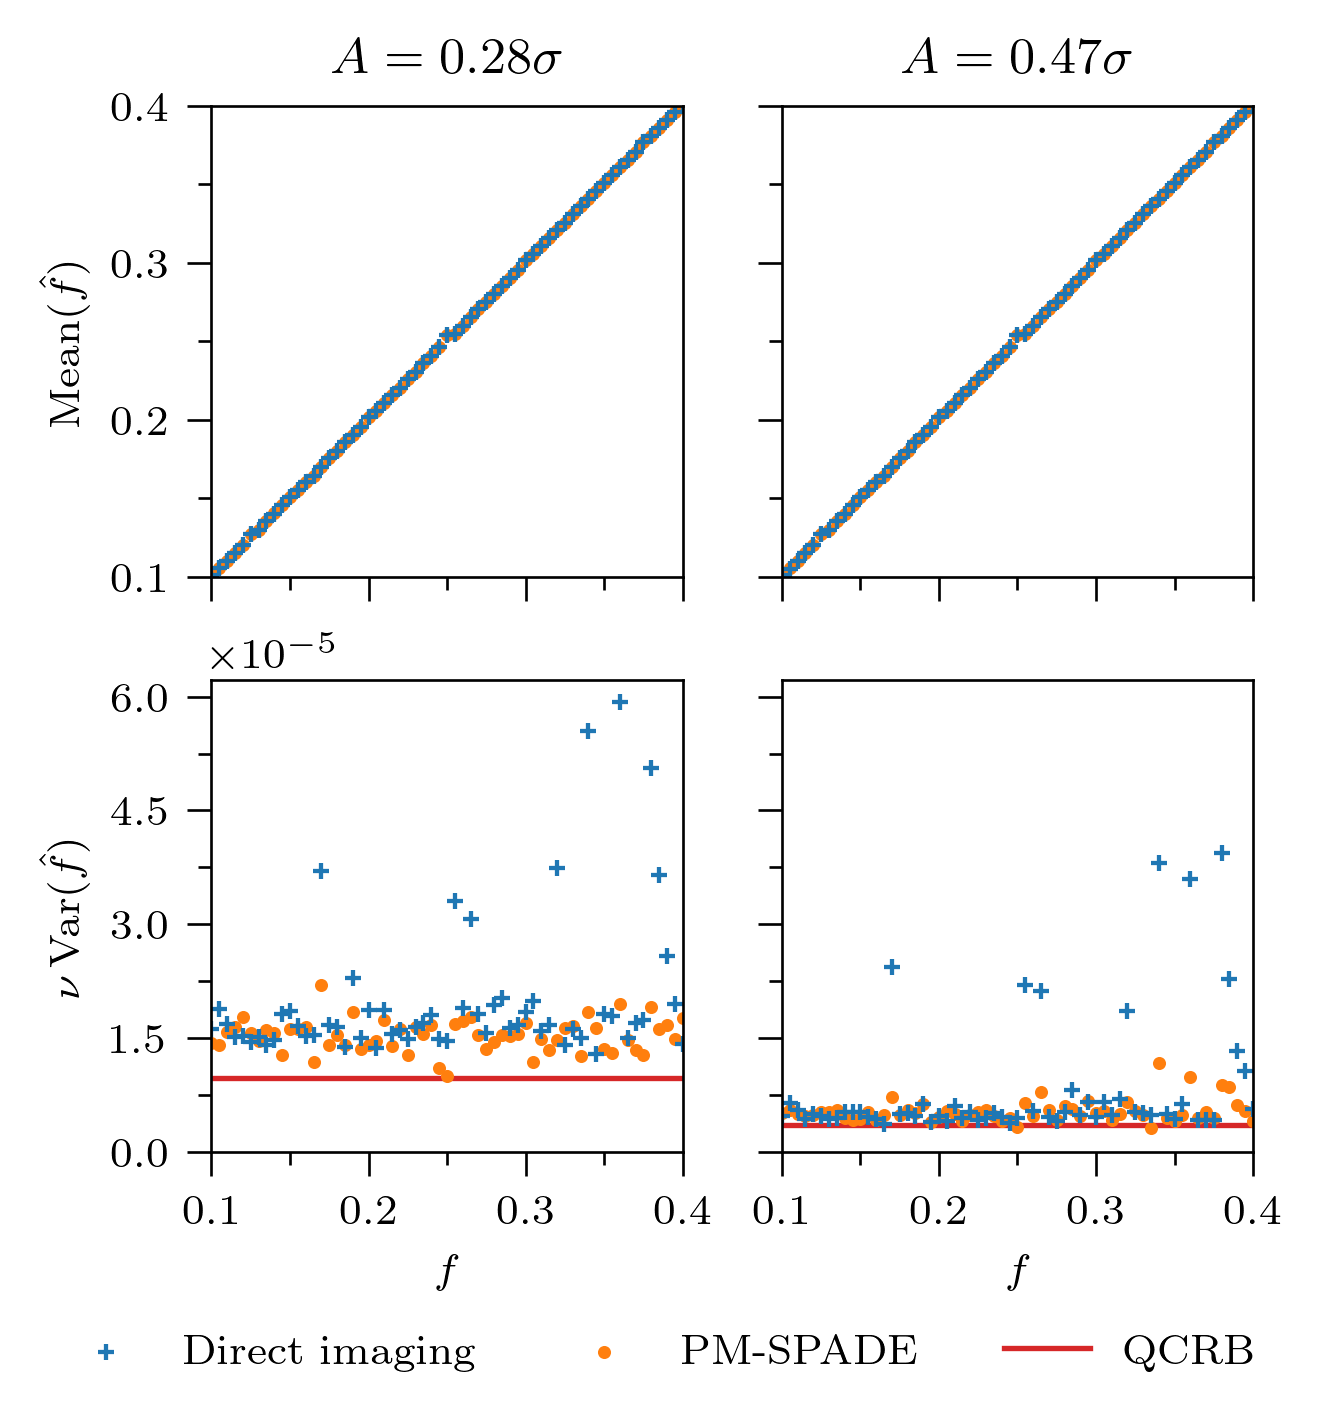

In [294]:
fig, ax = plt.subplots(2, 2, figsize=(width, width), sharex=True, sharey='row', constrained_layout=True)

axs = {
    3: (ax[0, 0], ax[1, 0]),
    5: (ax[0, 1], ax[1, 1])
}



for a in (3, 5):
    line1 = axs[a][0].scatter(spade_f[a], spade_mean[a], **spade_params)
    line2 = axs[a][0].scatter(di_f[a], di_mean[a], **di_params)
    # axs[a][0].plot(spade_f[a], spade_mean[a], linewidth=1, linestyle='--')
    # axs[a][0].plot(di_f[a], di_mean[a], linewidth=1, linestyle='-.')

    x_axis = np.linspace(0.1, 0.4, 61)
    fi = DI.ApproxCFI(4/np.pi*DMD.A(a))
    crb = np.ones(61) / fi
    line3, = axs[a][1].plot(x_axis, crb, qcrb_color, linewidth=1, zorder=1)

    axs[a][1].scatter(spade_f[a], spade_var[a], **spade_params)
    axs[a][1].scatter(di_f[a], di_var[a], **di_params)

    # axs[a][0].set_title(rf'${np.round(DMD.A(a)/103, 2)}\sigma$')
    # axs[a][1].set_title(rf'${np.round(DMD.A(a)/103, 2)}\sigma$')


for i, ax_ in enumerate(np.ravel(ax)):
    ax_.set_box_aspect(1)
    ax_.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax_.yaxis.set_minor_locator(AutoMinorLocator(2))
    # ax_.text(-0.15, 1.2, 
    #          [r'$\mathbf{\textsf{(' + _ + r')}}$' for _ in ('a', 'b', 'c', 'd')][i], 
    #          fontsize=9, transform=ax_.transAxes, va='top', ha='left')

# ax[0, 0].set_title(r'$A=0.28\sigma$', loc="right")
# ax[0, 1].set_title(r'$A=0.47\sigma$', loc="right")
# ax[1, 0].set_title(r'$A=0.28\sigma$', loc="right")
# ax[1, 1].set_title(r'$A=0.47\sigma$', loc="right")

ax[0, 0].set_title(r'$A=0.28\sigma$')
ax[0, 1].set_title(r'$A=0.47\sigma$')


ax[0, 0].set_xlim(0.1, 0.4)
ax[0, 0].set_ylim(0.1, 0.4)
ax[0, 0].set_xticks(np.linspace(0.1, 0.4, 4))
ax[0, 0].set_yticks(np.linspace(0.1, 0.4, 4))

ax[0, 0].set_ylabel(r'$\operatorname{Mean}(\hat f)$')
ax[1, 0].set_ylabel(r'$\nu\operatorname{Var}(\hat f)$')

ax[1, 0].set_xlabel(r'$f$')
ax[1, 1].set_xlabel(r'$f$')
ax[1, 0].set_yticks(np.linspace(0, 6, 5) * 1e-5)
ax[1, 0].yaxis.set_major_formatter(formatter)


fig.legend([line2, line1, line3], ['Direct imaging', 'PM-SPADE', 'QCRB'], ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.08), frameon=False)

# plt.tight_layout()
plt.savefig('fig3.pdf')
plt.show()

## Noisy

In [295]:
spade_mean, spade_var, spade_b = [np.load('result/expt/noisy/spade_5px.npz')[ff] for ff in ('mean', 'var', 'b')]
di_mean, di_var, di_b = [np.load('result/expt/noisy/di_5px.npz')[ff] for ff in ('mean', 'var', 'b')]

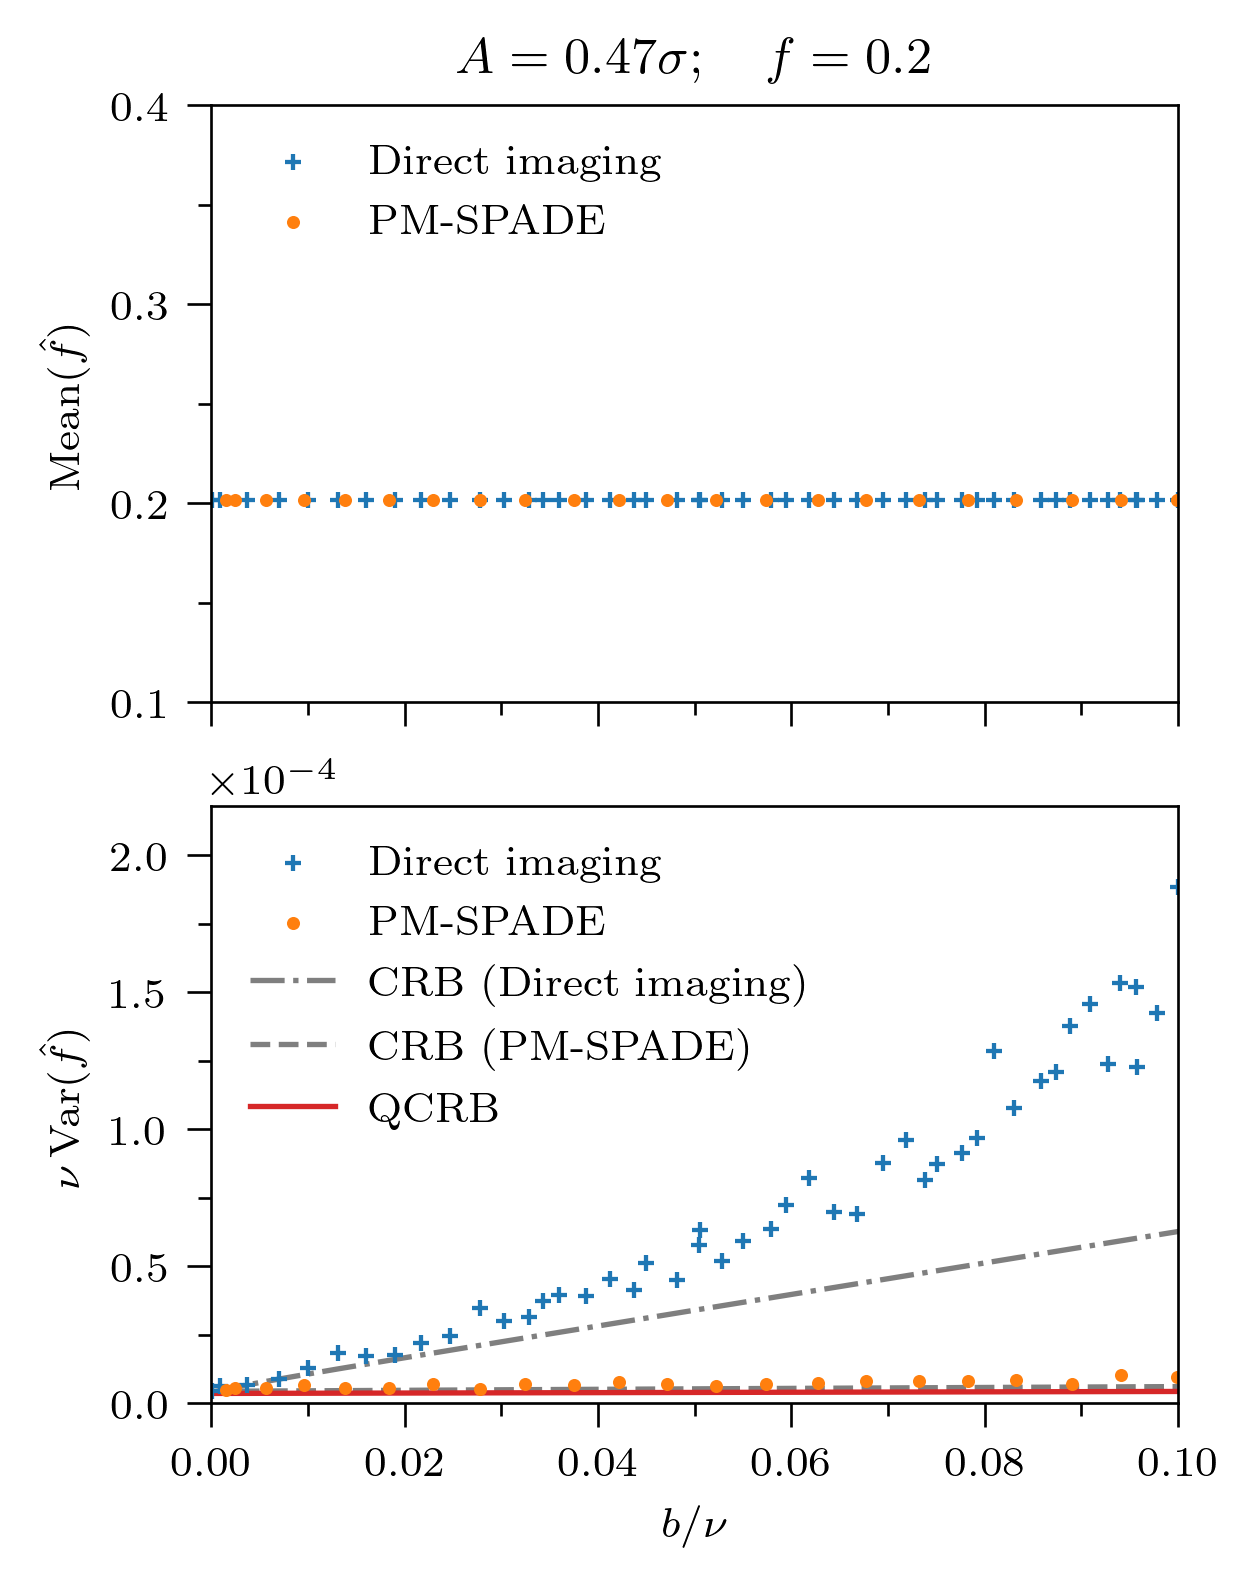

In [296]:
b_axis = np.linspace(1e-10, 0.2, 1000)
spade_crb = 1/SPADE.CFI(b_axis, (4/pi) * DMD.A(5), 0.2)
di_crb = 1/DI.CFI(b_axis, (4/pi) * DMD.A(5), 0.2)
qcrb = 1/QFI(b_axis, (4/pi) * DMD.A(5), 0.2)

fig, ax = plt.subplots(2, 1, figsize=(width, width*1.2), sharex=True, constrained_layout=True)

ax[0].scatter(di_b, di_mean, **di_params, label='Direct imaging')
ax[0].scatter(spade_b, spade_mean, **spade_params, label='PM-SPADE')
ax[0].set_ylim(0.1, 0.4)


ax[1].scatter(di_b, di_var, **di_params, label='Direct imaging', zorder=2)
ax[1].scatter(spade_b, spade_var, **spade_params, label='PM-SPADE', zorder=2)

# ax[1].scatter(di_b, di_var, **di_params, zorder=2)
# ax[1].scatter(spade_b, spade_var, **spade_params, zorder=2)


ax[1].plot(b_axis, di_crb, 
           linestyle='-.', linewidth=1, color=crb_color,
           label='CRB (Direct imaging)', zorder=1)
ax[1].plot(b_axis, spade_crb, 
           linestyle='--', linewidth=1, color=crb_color,
           label='CRB (PM-SPADE)', zorder=1)
ax[1].plot(b_axis, qcrb, 
           linestyle='-', linewidth=1, color=qcrb_color, 
           label='QCRB', zorder=1)



ax[1].yaxis.set_major_formatter(formatter)
ax[1].set_ylim(0, 2.18e-4)


ax[0].set_ylabel(r'$\operatorname{Mean}(\hat f)$')
ax[1].set_xlabel(r'$b/\nu$')
ax[1].set_ylabel(r'$\nu\operatorname{Var}(\hat f)$')
ax[0].set_title(r'$A = 0.47\sigma;\quad f=0.2$')

for ax_ in ax:
    ax_.set_xlim(0, 0.1)
    ax_.set_box_aspect(0.618)
    ax_.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax_.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax_.legend(loc='upper left', frameon=False)
    

plt.savefig('fig4.pdf')
plt.show()

---
# Supplemental Material

## $\gamma$

In [ ]:
params = {
    'zorder': 3,
    'clip_on': False,
    'linewidth': 1.35,
}

fig = plt.figure(figsize=(width, width))

s = 0.5 * DI.SIGMA

def i(b, sigma=DI.SIGMA):
    from scipy.integrate import quad
    b_ = b * sigma
    func = lambda x: (x**2 * np.exp(-x**2)) / (np.sqrt(2*np.pi)*np.exp(-x**2/2) + 2*np.pi*b_)
    return quad(func, -np.inf, np.inf)[0] / sigma**2

x = np.linspace(1e-10, 1, 300)
y_DI_continue = np.array([i(x_) for x_ in x]) * DI.SIGMA**2
y_DI = np.array([DI.gamma(b, s) for b in x]) * DI.SIGMA**2
y_PM = np.array([PM_SPADE.gamma(b, s) for b in x]) * DI.SIGMA**2
y_HG = np.array([HG_SPADE.gamma(b, s) for b in x]) * DI.SIGMA**2


plt.plot(x, y_DI_continue, label=r'Direct imaging (infinitesimal $a$)', linestyle='-', color='tab:purple', **params)
plt.plot(x, y_DI, label=r'Direct imaging ($a=4.6\,$\textmu m)', linestyle='-.', color='k', **params)
plt.plot(x, y_PM, label=r'PM-SPADE', linestyle='--', color='tab:blue', **params)
plt.plot(x, y_HG, label=r'HG-SPADE', linestyle=(0, (1, 1)), color='tab:green', **params)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel(r"$b/\nu$")
plt.ylabel(r'$\sigma^2\gamma$')

plt.gca().set_box_aspect(0.618)
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2)) 
plt.legend(frameon=False, loc='upper right')
plt.title(r'$s=0.5\sigma$')
plt.tight_layout()
plt.savefig('gamma.pdf', bbox_inches='tight')

plt.show()

In [ ]:
# fig, axes = plt.subplots(1, 2, sharex=True, sharey=False, constrained_layout=True, figsize=(width*2, width))

params = {
    'zorder': 3,
    'clip_on': False,
    'linewidth': 1,
}

fig = plt.figure(figsize=(width, width))

s = 0.47 * DI.SIGMA

def i(b, sigma=DI.SIGMA):
    from scipy.integrate import quad
    b_ = b * sigma
    func = lambda x: (x**2 * np.exp(-x**2)) / (np.sqrt(2*np.pi)*np.exp(-x**2/2) + 2*np.pi*b_)
    return quad(func, -np.inf, np.inf)[0] / sigma**2

x = np.linspace(1e-10, 0.01, 300)
y_DI_continue = np.array([i(x_) for x_ in x]) * DI.SIGMA**2
y_DI = np.array([DI.gamma(b, s) for b in x]) * DI.SIGMA**2
y_PM = np.array([PM_SPADE.gamma(b, s) for b in x]) * DI.SIGMA**2
y_HG = np.array([HG_SPADE.gamma(b, s) for b in x]) * DI.SIGMA**2


plt.plot(x, y_DI_continue, label=r'Direct imaging (infinitesimal $a$)', linestyle=(0, (5, 1, 1, 1, 1, 1)), color='tab:purple', **params)
plt.plot(x, y_DI, label=r'Direct imaging ($a=4.6\,$\textmu m)', linestyle='-.', color='k', **params)
plt.plot(x, y_PM, label=r'PM-SPADE', linestyle='--', color='tab:blue', **params)
plt.plot(x, y_HG, label=r'HG-SPADE', linestyle=(0, (1, 1)), color='tab:green', **params)
# plt.yscale('log')
plt.xlim(0, 0.01)
plt.ylim(0, 1)
plt.xlabel(r"$b/\nu$")
plt.ylabel(r'$\sigma^2\gamma$')

plt.gca().set_box_aspect(0.618)
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
# plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2)) 
plt.legend(frameon=False)
plt.title(r'$s=0.47\sigma$')
plt.tight_layout()
# plt.savefig('gamma.pdf', bbox_inches='tight')

plt.show()

## CFI

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(width * 1.6, width * 1.1), sharex='col', constrained_layout=True)

params = {
    'di': dict(label='Direct imaging', linestyle='-.', color='k', zorder=3, linewidth=1.35),
    'pm': dict(label='PM-SPADE', linestyle='--', color='tab:blue', zorder=3, linewidth=1.35),
    'hg': dict(label='HG-SPADE', linestyle=(0, (1, 1)), color='tab:green', zorder=3, linewidth=1.35),
    'qfi': dict(label='QFI', linestyle='-', color='tab:red', zorder=2, linewidth=1.35),
}


# (0, 0)
b_range = np.linspace(0, 0.1, 300)
A = DMD.A(5)
qfi_ideal = QFI(0, A, 0.2)
ax = axes[0, 0]

ax.plot(b_range, [DI.CFI(b, A, 0.2) / qfi_ideal for b in b_range], **params['di'], clip_on=False)
ax.plot(b_range, [PM_SPADE.CFI(b, A, 0.2) / qfi_ideal for b in b_range], **params['pm'], clip_on=False)
ax.plot(b_range, [HG_SPADE.CFI(b, A, 0.2) / qfi_ideal for b in b_range], **params['hg'], clip_on=False)
ax.plot(b_range, [QFI(b, A, 0.2) / qfi_ideal for b in b_range], **params['qfi'], clip_on=False)


# (0, 1)
b_range = np.linspace(100, 1000, 300)
ax = axes[0, 1]

ax.plot(b_range, [DI.CFI(b, A, 0.2) / qfi_ideal for b in b_range], **params['di'], clip_on=False)
ax.plot(b_range, [PM_SPADE.CFI(b, A, 0.2) / qfi_ideal for b in b_range], **params['pm'], clip_on=False)
ax.plot(b_range, [HG_SPADE.CFI(b, A, 0.2) / qfi_ideal for b in b_range], **params['hg'], clip_on=False)
ax.plot(b_range, [QFI(b, A, 0.2) / qfi_ideal for b in b_range], **params['qfi'], clip_on=False)


# (1, 0)
b_range = np.linspace(0, 0.1, 300)
A = 0.01 * DI.SIGMA
qfi_ideal = QFI(0, A, 0.2)
ax = axes[1, 0]

ax.plot(b_range, [DI.CFI(b, A, 0.2) / qfi_ideal for b in b_range], **params['di'], clip_on=False)
ax.plot(b_range, [PM_SPADE.CFI(b, A, 0.2) / qfi_ideal for b in b_range], **params['pm'], clip_on=False)
ax.plot(b_range, [HG_SPADE.CFI(b, A, 0.2) / qfi_ideal for b in b_range], **params['hg'], clip_on=False)
ax.plot(b_range, [QFI(b, A, 0.2) / qfi_ideal for b in b_range], **params['qfi'], clip_on=False)
ax.set_xlabel(r'$b / \nu$')



# (1, 1) + inset
b_range = np.linspace(100, 1000, 300)
qfi_ideal = QFI(0, A, 0.2)
ax = axes[1, 1]

di_, = ax.plot(b_range, [DI.CFI(b, A, 0.2) / qfi_ideal for b in b_range], **params['di'], clip_on=False)
pm_, = ax.plot(b_range, [PM_SPADE.CFI(b, A, 0.2) / qfi_ideal for b in b_range], **params['pm'], clip_on=False)
hg_, = ax.plot(b_range, [HG_SPADE.CFI(b, A, 0.2) / qfi_ideal for b in b_range], **params['hg'], clip_on=False)
qfi_, = ax.plot(b_range, [QFI(b, A, 0.2) / qfi_ideal for b in b_range], **params['qfi'], clip_on=False)
ax.set_xlabel(r'$b / \nu$')
ax.set_xticks(np.linspace(100, 1000, 4), np.linspace(100, 1000, 4).astype(int))

# inset
ax_inset = inset_axes(ax, width='40%', height='40%', loc='upper right', borderpad=1.5)
ax_inset.plot(b_range, [DI.CFI(b, A, 0.2) / qfi_ideal for b in b_range], **params['di'])
ax_inset.plot(b_range, [PM_SPADE.CFI(b, A, 0.2) / qfi_ideal for b in b_range], **params['pm'])
ax_inset.plot(b_range, [HG_SPADE.CFI(b, A, 0.2) / qfi_ideal for b in b_range], **params['hg'], clip_on=False)
ax_inset.set_xlim(100, 1000)
ax_inset.set_ylim(0, 1.42e-5)

ax_inset.yaxis.set_major_formatter(formatter)
ax_inset.set_xticks(np.linspace(100, 1000, 4), np.linspace(100, 1000, 4).astype(int))
ax_inset.xaxis.set_minor_locator(AutoMinorLocator(2))
ax_inset.yaxis.set_minor_locator(AutoMinorLocator(2))


for ax in axes.ravel():
    ax.set_box_aspect(0.618)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.set_ylabel(r'Normalized FI')
    ax.yaxis.set_major_formatter(formatter)

for i in (0, 1):
    axes[0, i].set_title(r'$A=0.47\sigma;\quad f=0.2$')
    axes[1, i].set_title(r'$A=0.01\sigma;\quad f=0.2$')

    axes[i, 0].set_xlim(0, 0.1)
    axes[i, 0].set_ylim(0, 1)

    axes[i, 1].set_xlim(100, 1000)
    axes[i, 1].set_ylim(0, None)


fig.legend([di_, pm_, hg_, qfi_], 
           [r'$F^\text{(DI)}$', r'$F^\text{(PM)}$', r'$F^\text{(HG)}$', r'$\mathcal{F}$'], 
           ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.08), frameon=False)

plt.savefig('fi.pdf')
plt.show()


In [ ]:
fig, axes = plt.subplots(2, 2, sharex='col', constrained_layout=True, figsize=(width * 1.6, width * 1.1))

params = {
    'di': dict(label=r'$F^\text{(DI)}$', linestyle='-.', color='k', linewidth=1.5, zorder=3, clip_on=False),
    'pm': dict(label=r'$F^\text{(PM)}$', linestyle='--', color='tab:blue', linewidth=1.5, zorder=3, clip_on=False),
    'hg': dict(label=r'$F^\text{(HG)}$', linestyle=(0, (1, 1)), color='tab:green', linewidth=1.5, zorder=3, clip_on=False),
    'qfi': dict(label=r'$\mathcal{F}$', linestyle='-', color='tab:red', linewidth=1.5, zorder=3, clip_on=False),
}

b_range = np.linspace(1e-10, 0.005, 300)
A = DMD.A(5)
qfi_ideal = QFI(0, A, 0.2)
ax = axes[0, 0]

ax.plot(b_range, QFI(b_range, A, 0.2) / qfi_ideal, **params['qfi'])
ax.plot(b_range, DI.CFI(b_range, A, 0.2) / qfi_ideal, **params['di'])
ax.plot(b_range, SPADE.CFI(b_range, A, 0.2) / qfi_ideal, **params['pm'])
ax.plot(b_range, HG_SPADE.CFI(b_range, A, 0.2) / qfi_ideal, **params['hg'])
ax.set_xlim(0, 0.005)
ax.set_ylim(0, 1)
ax.set_title(r'$A=0.47\sigma;\quad f=0.2$')


b_range = np.linspace(1e-10, 0.005, 300)
A = 0.01 * DI.SIGMA
qfi_ideal = QFI(0, A, 0.2)
ax = axes[1, 0]

ax.plot(b_range, QFI(b_range, A, 0.2) / qfi_ideal, **params['qfi'])
ax.plot(b_range, DI.CFI(b_range, A, 0.2) / qfi_ideal, **params['di'])
ax.plot(b_range, SPADE.CFI(b_range, A, 0.2) / qfi_ideal, **params['pm'])
ax.plot(b_range, HG_SPADE.CFI(b_range, A, 0.2) / qfi_ideal, **params['hg'])
ax.set_xlim(0, 0.005)
ax.set_ylim(0, 1)
ax.set_title(r'$A=0.01\sigma;\quad f=0.2$')


b_range = np.linspace(1e-10, 100, 300)
A = DMD.A(5)
qfi_ideal = QFI(0, A, 0.2)
ax = axes[0, 1]

ax.plot(b_range, QFI(b_range, A, 0.2) / qfi_ideal, **params['qfi'])
ax.plot(b_range, DI.CFI(b_range, A, 0.2) / qfi_ideal, **params['di'])
ax.plot(b_range, SPADE.CFI(b_range, A, 0.2) / qfi_ideal, **params['pm'])
ax.plot(b_range, HG_SPADE.CFI(b_range, A, 0.2) / qfi_ideal, **params['hg'])
ax.set_yscale('log')
ax.set_xlim(0, 100)
ax.set_ylim(None, 1)
ax.set_title(r'$A=0.47\sigma;\quad f=0.2$')


A = 0.01*DI.SIGMA
qfi_ideal = QFI(0, A, 0.2)
ax = axes[1, 1]

ax.plot(b_range, QFI(b_range, A, 0.2) / qfi_ideal, **params['qfi'])
ax.plot(b_range, DI.CFI(b_range, A, 0.2) / qfi_ideal, **params['di'])
ax.plot(b_range, SPADE.CFI(b_range, A, 0.2) / qfi_ideal, **params['pm'])
ax.plot(b_range, HG_SPADE.CFI(b_range, A, 0.2) / qfi_ideal, **params['hg'])
ax.set_yscale('log')
ax.set_xlim(0, 100)
ax.set_ylim(None, 1)
ax.set_title(r'$A=0.01\sigma;\quad f=0.2$')


for ax in axes.ravel():
    ax.set_box_aspect(0.618)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.set_ylabel(r'Normalized FI')
    # ax.legend(frameon=False, ncol=2)

axes[1, 0].set_xlabel(r'$b/\nu$')
axes[1, 1].set_xlabel(r'$b/\nu$')
axes[0, 0].yaxis.set_minor_locator(AutoMinorLocator(2))
axes[1, 0].yaxis.set_minor_locator(AutoMinorLocator(2))

axes[1, 1].yaxis.set_minor_locator(mpl.ticker.LogLocator(base=10, subs = np.arange(2, 10) * 0.1, numticks=10))
axes[1, 1].set_yticks([1e0, 1e-2, 1e-4, 1e-6])
# axes[1, 1].yaxis.set_minor_locator(mpl.ticker.LogLocator(base=10.0, numticks=10))

fig.legend([di_, pm_, hg_, qfi_], 
           [r'$F^\text{(DI)}$', r'$F^\text{(PM)}$', r'$F^\text{(HG)}$', r'$\mathcal{F}$'], 
           ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.08), frameon=False)

plt.savefig('fi.pdf')
plt.show()

## Intuitive

In [ ]:
def plot_data():
    def binning(c):
        binned_1 = qCMOS.convert2photons(c.cropped_data[0, 0], 0).reshape(-1, 8).sum(-1)
        binned_2 = qCMOS.convert2photons(c.cropped_data[0, 4], 0).reshape(-1, 8).sum(-1)

        return binned_1, binned_2

    binned_1, binned_2 = binning(LoadEstimates('data/noisy/di_5px_f0.2_d0.npz'))
    binned_3, binned_4 = binning(LoadEstimates('data/noisy/di_5px_f0.2_d92.npz'))


    width = 0.18
    spade_c1 = LoadEstimates('data/noisy/spade_5px_f0.2_d0.npz')
    spade_c2 = LoadEstimates('data/noisy/spade_5px_f0.2_d42.npz')

    y1 = qCMOS.convert2photons(spade_c1.cropped_data[0, 0], 0)
    y2 = qCMOS.convert2photons(spade_c1.cropped_data[0, 4], 0)

    y3 = qCMOS.convert2photons(spade_c2.cropped_data[0, 0], 0)
    y4 = qCMOS.convert2photons(spade_c2.cropped_data[0, 4], 0)

    _plot_data = [
        [np.arange(25)+0.5, binned_1], [np.arange(25)+0.5, binned_2],  # ax[0, 0]
        [np.arange(25)+0.5, binned_3], [np.arange(25)+0.5, binned_4],  # ax[1, 0]

        [[0, (1 - 0.2)], [y1[0], y1[1]]], [[(0.02+width), (1.02+width - 0.2)], [y2[0], y2[1]]],  # ax[0, 1]
        [[0, (1 - 0.2)], [y3[0], y3[1]]], [[(0.02+width), (1.02+width - 0.2)], [y4[0], y4[1]]]   # ax[1, 1]
    ]

    return _plot_data


di_ideal = np.load(r'raw\noisy\di_5px\di_5px_f0.2_d0_raw.npy')
di_noisy = np.load(r'raw\noisy\di_5px\di_5px_f0.2_d92_raw.npy')


pm_ideal = np.load(r'raw\noisy\spade_5px\spade_5px_f0.2_d0_raw.npy')
pm_noisy = np.load(r'raw\noisy\spade_5px\spade_5px_f0.2_d42_raw.npy')

# di_ideal = np.load(r'raw\ideal\di_5px\di_5px_f0.1_d0_raw.npy')
# di_noisy = np.load(r'raw\ideal\di_5px\di_5px_f0.4_d0_raw.npy')


# pm_ideal = np.load(r'raw\ideal\spade_5px\spade_5px_f0.1_d0_raw.npy')
# pm_noisy = np.load(r'raw\ideal\spade_5px\spade_5px_f0.4_d0_raw.npy')


raw = {
    'di_ideal': {'0': qCMOS.convert2photons(di_ideal[0, 0, :-4, :].astype(float), 0),
                '2a': qCMOS.convert2photons(di_ideal[0, 4, :-4, :].astype(float), 0)},

    'di_noisy': {'0': qCMOS.convert2photons(di_noisy[0, 0, :-4, :].astype(float), 0),
                '2a': qCMOS.convert2photons(di_noisy[0, 4, :-4, :].astype(float), 0)},

    'pm_ideal': {'0': qCMOS.convert2photons(pm_ideal[0, 0, :-4, :].astype(float), 0),
                '2a': qCMOS.convert2photons(pm_ideal[0, 4, :-4, :].astype(float), 0)},

    'pm_noisy': {'0': qCMOS.convert2photons(pm_noisy[0, 0, :-4, :].astype(float), 0),
                '2a': qCMOS.convert2photons(pm_noisy[0, 4, :-4, :].astype(float), 0)},
}


limit = {
    'di_ideal': {'vmin': min(raw['di_ideal']['0'].min(), raw['di_ideal']['2a'].min()),
                 'vmax': max(raw['di_ideal']['0'].max(), raw['di_ideal']['2a'].max())},

    'di_noisy': {'vmin': min(raw['di_noisy']['0'].min(), raw['di_noisy']['2a'].min()),
                 'vmax': max(raw['di_noisy']['0'].max(), raw['di_noisy']['2a'].max())},

    'pm_ideal': {'vmin': min(raw['pm_ideal']['0'].min(), raw['pm_ideal']['2a'].min()),
                 'vmax': max(raw['pm_ideal']['0'].max(), raw['pm_ideal']['2a'].max())},

    'pm_noisy': {'vmin': min(raw['pm_noisy']['0'].min(), raw['pm_noisy']['2a'].min()),
                 'vmax': max(raw['pm_noisy']['0'].max(), raw['pm_noisy']['2a'].max())},
}

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(width * 1.6, width * 1.1), sharex='col', constrained_layout=True)

data = plot_data()

params = dict(alpha=0.6, edgecolor='black', linewidth=0.5)

axes[0, 0].bar(*data[0], label=r'$s=0$', **params)
axes[0, 0].bar(*data[1], label=r'$s=2A$', **params)

axes[1, 0].bar(*data[2], label=r'$s=0$', **params)
axes[1, 0].bar(*data[3], label=r'$s=2A$', **params)

axes[0, 1].bar(*data[4], width=0.18, label=r'$s=0$', **params)
axes[0, 1].bar(*data[5], width=0.18, label=r'$s=2A$', **params)

axes[1, 1].bar(*data[6], width=0.18, label=r'$s=0$', **params)
axes[1, 1].bar(*data[7], width=0.18, label=r'$s=2A$', **params)

axes[0, 0].set_title('Direct imaging')
axes[0, 1].set_title('PM-SPADE')

axes[0, 0].set_ylabel('Photons (binned)')
axes[1, 0].set_ylabel('Photons (binned)')

axes[0, 1].tick_params(axis='x', which='minor', bottom=False, top=False)
axes[1, 1].tick_params(axis='x', which='minor', bottom=False, top=False)

axes[0, 0].set_xticks(np.linspace(0, 25, 6), np.linspace(0, 200, 6).astype(int))
axes[1, 0].set_xticks(np.linspace(0, 25, 6), np.linspace(0, 200, 6).astype(int))

axes[0, 0].set_xlim(0, 25)
axes[1, 0].set_xlim(0, 25)

axes[0, 1].set_xlim(-0.5, 1.5)
axes[1, 1].set_xlim(-0.5, 1.5)

axes[0, 0].set_ylim(0, 80*1.02)
axes[1, 0].set_ylim(0, 1500*1.02)
axes[0, 1].set_ylim(0, 130*1.02)
axes[1, 1].set_ylim(0, 140*1.02)

axes[1, 0].set_xlabel('Pixel (binned)')
axes[1, 1].set_xlabel('Mode')
axes[0, 1].set_ylabel('Photons')
axes[1, 1].set_ylabel('Photons')
axes[0, 1].set_xticks([0.1, 1.1 - 0.2], [r'$\phi_+$', r'$\phi_-$'])
axes[1, 1].set_xticks([0.1, 1.1 - 0.2], [r'$\phi_+$', r'$\phi_-$'])

for i, ax in enumerate(axes.ravel()):
    ax.set_box_aspect(0.618)
    ax.legend(frameon=False, loc='upper left')
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))



for i, fig_name in enumerate(['di_ideal', 'di_noisy']):
    inset1 = inset_axes(axes[i, 0], width=0.4, height=0.4, loc='upper right', bbox_to_anchor=(0.85, 1), bbox_transform=axes[i, 0].transAxes)
    inset1.imshow(raw[fig_name]['0'], **limit[fig_name])
    inset1.scatter([DI.X_AXIS]*20, np.linspace(0, 223, 20), s=1, color='tab:blue', edgecolor='black', linewidths=0.3)
    inset1.set_xticks([])
    inset1.set_yticks([])

    inset2 = inset_axes(axes[i, 0], width=0.4, height=0.4, loc='upper right', bbox_to_anchor=(1.02, 1), bbox_transform=axes[i, 0].transAxes)
    inset2.imshow(raw[fig_name]['2a'], **limit[fig_name])
    inset2.scatter([DI.X_AXIS]*20, np.linspace(0, 223, 20), s=1, color='tab:orange', edgecolor='black', linewidths=0.3)
    inset2.set_xticks([])
    inset2.set_yticks([])


for i, fig_name in enumerate(['pm_ideal', 'pm_noisy']):
    inset1 = inset_axes(axes[i, 1], width=0.6, height=0.6, loc='upper right', bbox_to_anchor=(0.95, 1), bbox_transform=axes[i, 1].transAxes)
    inset1.imshow(raw[fig_name]['0'], **limit[fig_name])
    inset1.scatter([SPADE.X_AXIS]*2, [SPADE.POINT_1, SPADE.POINT_2], color='tab:blue', marker='X', edgecolors='black', linewidths=0.3, s=5)
    inset1.set_xticks([])
    inset1.set_yticks([])

    inset2 = inset_axes(axes[i, 1], width=0.6, height=0.6, loc='upper right', bbox_to_anchor=(1.085, 1), bbox_transform=axes[i, 1].transAxes)
    inset2.imshow(raw[fig_name]['2a'], **limit[fig_name])
    inset2.scatter([SPADE.X_AXIS]*2, [SPADE.POINT_1, SPADE.POINT_2], color='tab:orange', marker='X', edgecolors='black', linewidths=0.3, s=5)
    inset2.set_xticks([])
    inset2.set_yticks([])

plt.savefig('intuitive.pdf')
plt.show()

## Simulation

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(width * 2, width * 0.9), sharex='col', constrained_layout=True)
freq_list = np.linspace(0.1, 0.4, 61)
b_list = np.linspace(0, 0.1, 21)

for j, a in enumerate((3, 5)):
    fi = DI.ApproxCFI((4 / pi) * DMD.A(a))
    axes[0, j].axhline(1/fi, color=qcrb_color, zorder=3, alpha=0.8)
    axes[1, j].axhline(1/fi, color=qcrb_color, zorder=3, alpha=0.8)

qcrb = axes[1, 2].axhline(1/fi, color=qcrb_color, zorder=3, alpha=0.8)

hg_crb, = axes[1, 3].plot(np.linspace(0, 0.1, 100), 
                          1/HG_SPADE.CFI(np.linspace(0, 0.1, 100), (4/pi) * DMD.A(5), 0.2), linestyle=(0, (1, 1)), color=crb_color, zorder=3, alpha=0.8)

pm_crb, = axes[1, 3].plot(np.linspace(0, 0.1, 100), 
                          1/PM_SPADE.CFI(np.linspace(0, 0.1, 100), (4/pi) * DMD.A(5), 0.2), '--', color=crb_color, zorder=3, alpha=0.8)

di_crb, = axes[1, 3].plot(np.linspace(0, 0.1, 100), 
                          1/DI.CFI(np.linspace(0, 0.1, 100), (4/pi) * DMD.A(5), 0.2), '-.', color=crb_color, zorder=3, alpha=0.8)

f_var_max = 0
for k, w in enumerate(('SIN', 'SIGN')):
    for j, a in enumerate((3, 5)):
        for m in ('SPADE', 'DI'):

            f_var = np.load(rf'result/sim/{w.lower()}/{m.lower()}_{a}px.npz')['var']

            if m.lower() == 'spade':
                axes[k, j].scatter(freq_list, f_var, **spade_params, label=m)
            elif m.lower() == 'di':
                axes[k, j].scatter(freq_list, f_var, **di_params, label=m)

            f_var_max = max(f_var_max, np.max(f_var))


# axes[0, 0].set_title(r'$0.28 \sigma \cdot \sin(2\pi f n)$', loc="right")
# axes[0, 1].set_title(r'$0.47 \sigma \cdot \sin(2\pi f n)$', loc="right")
# axes[1, 0].set_title(r'$0.28 \sigma \cdot \operatorname{sgn}\qty[\sin(2\pi f n)]$', loc="right")
# axes[1, 1].set_title(r'$0.47 \sigma \cdot \operatorname{sgn}\qty[\sin(2\pi f n)]$', loc="right")

for i, ax in enumerate(axes.T.ravel()):
    t = 'abcdefghijklmn'
    ax: plt.Axes
    ax.set_title(rf'({t[i]})')
    ax.set_box_aspect(1)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_major_formatter(formatter)

for i, ax in enumerate(axes.T.ravel()[:4]):
    ax.set_ylabel(r'$\nu\operatorname{Var}(\hat f)$')
    ax.set_ylim(0, f_var_max * 1.05)
    ax.set_xticks(np.linspace(0.1, 0.4, 4))
    temp_formatter = ScalarFormatter(useMathText=True)
    temp_formatter.set_powerlimits((-5, -5))
    ax.yaxis.set_major_formatter(temp_formatter)

for i in range(2, 4):
    axes[0, i].set_ylabel(r'$\operatorname{Mean}(\hat f)$')
    axes[0, i].set_ylim(0.1, 0.4)
    axes[0, i].set_yticks(np.linspace(0.1, 0.4, 4))
    axes[1, i].set_ylabel(r'$\nu\operatorname{Var}(\hat f)$')

for i in range(3):
    axes[1, i].set_xlim(0.1, 0.4)
    axes[1, i].set_xlabel(r'$f$')
    axes[1, i].set_xticks(np.linspace(0.1, 0.4, 4))

axes[1, 3].set_xlabel(r'$b/\nu$')
axes[1, 3].set_xlim(0, 0.1)
axes[1, 3].set_ylim(0, 2.18e-4)
axes[1, 2].set_ylim(0, 1.04*6e-5)



f_mean_list, f_var_list = np.load(f'result/sim/ideal/hg_5px.npz')['mean'], np.load(f'result/sim/ideal/hg_5px.npz')['var']
hg = axes[0, 2].scatter(freq_list, f_mean_list, **hg_params)
hg = axes[1, 2].scatter(freq_list, f_var_list, **hg_params)

f_mean_list, f_var_list = np.load(f'result/sim/ideal/spade_5px.npz')['mean'], np.load(f'result/sim/ideal/spade_5px.npz')['var']
pm = axes[0, 2].scatter(freq_list, f_mean_list, **spade_params)
pm = axes[1, 2].scatter(freq_list, f_var_list, **spade_params)

f_mean_list, f_var_list = np.load(f'result/sim/ideal/di_5px.npz')['mean'], np.load(f'result/sim/ideal/di_5px.npz')['var']
di = axes[0, 2].scatter(freq_list, f_mean_list, **di_params)
di = axes[1, 2].scatter(freq_list, f_var_list, **di_params)



f_mean_list, f_var_list = np.load(f'result/sim/noisy/hg_5px.npz')['mean'], np.load(f'result/sim/noisy/hg_5px.npz')['var']
axes[0, 3].scatter(b_list, f_mean_list, **hg_params)
hg = axes[1, 3].scatter(b_list, f_var_list, **hg_params)

f_mean_list, f_var_list = np.load(f'result/sim/noisy/spade_5px.npz')['mean'], np.load(f'result/sim/noisy/spade_5px.npz')['var']
axes[0, 3].scatter(b_list, f_mean_list, **spade_params)
pm = axes[1, 3].scatter(b_list, f_var_list, **spade_params)

f_mean_list, f_var_list = np.load(f'result/sim/noisy/di_5px.npz')['mean'], np.load(f'result/sim/noisy/di_5px.npz')['var']
axes[0, 3].scatter(b_list, f_mean_list, **di_params)
di = axes[1, 3].scatter(b_list, f_var_list, **di_params)


fig.legend([di, pm, hg], ['Direct imaging', 'PM-SPADE', 'HG-SPADE'],
                      ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.1), frameon=False)

fig.legend([qcrb, di_crb, pm_crb, hg_crb], ['QCRB', 'CRB (Direct imaging)', 'CRB (PM-SPADE)', 'CRB (HG-SPADE)'],
            ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.16), frameon=False)


plt.savefig('sim_8in1.pdf')
plt.show()